In [4]:
import numpy as np
from scipy.special import jv

# ==========================================
# 1. 定义物理模型类
# ==========================================

class PowerLawModel:
    """描述形如 A * (f / f_ref)^index 的幂律物理量"""
    def __init__(self, val_ref, f_ref, index, name="Parameter"):
        self.val_ref = val_ref
        self.f_ref = f_ref
        self.index = index
        self.name = name

    def evaluate(self, f):
        return self.val_ref * (f / self.f_ref) ** self.index

class PiecewiseSpeedModel:
    """
    分段波速模型：
    - f <= f1: 恒定为 c1
    - f >= f2: 恒定为 c2
    - f1 < f < f2: 随 log10(f) 线性插值
    """
    def __init__(self, f1=0.05, c1=2.0, f2=0.30, c2=0.5, name="Piecewise Speed"):
        self.f1 = f1
        self.c1 = c1
        self.f2 = f2
        self.c2 = c2
        self.name = name

    def evaluate(self, f):
        f = np.asarray(f)
        c = np.zeros_like(f)
        
        # 频率分段掩码
        mask1 = f <= self.f1
        mask2 = f >= self.f2
        mask_mid = ~(mask1 | mask2)
        
        c[mask1] = self.c1
        c[mask2] = self.c2
        
        # 核心插值：对 log10(f) 进行线性插值
        if np.any(mask_mid):
            log_f1 = np.log10(self.f1)
            log_f2 = np.log10(self.f2)
            log_f_mid = np.log10(f[mask_mid])
            
            slope = (self.c2 - self.c1) / (log_f2 - log_f1)
            c[mask_mid] = self.c1 + slope * (log_f_mid - log_f1)
            
        return c

def calculate_geometry_factor(f, r, speed_model):
    """计算阵列几何因子 G"""
    c_R = speed_model.evaluate(f)
    zeta = 2 * np.pi * f * r / c_R
    
    term_j0 = jv(0, zeta)
    term_j2 = jv(2, zeta)
    
    geo_factor = np.sqrt(np.abs(1 + term_j0 - 0.5 * term_j2)) / np.sqrt(2)
    return geo_factor

def calculate_array_noise(f, nu, r, noise_model, speed_model):
    """
    计算阵列等效噪声 ASD (单位: m/sqrt(Hz))
    """
    noise_asd = noise_model.evaluate(f)
    geo_factor = calculate_geometry_factor(f, r, speed_model)
    
    # 根据要求：固定 transfer_params=1 且直接绘制噪声，故不再乘以 sqrt(f) 也不除以响应函数
    noise_full = nu * noise_asd * geo_factor
    noise_flat = nu * noise_asd * 1.0  # 对照组：几何因子恒为 1
    
    return noise_full, noise_flat

In [12]:
import os

# ==========================================
# 2. 参数设置与数据读取
# ==========================================

freq_array = np.logspace(-2, 1, 1000) # 10^-2 到 10^0.5 (Hz)

# 基础物理常数 (保持原样)
nu_const = 0.5
r_const = 0.8  # km

# 基础噪声谱 (ASD)
noise_params = PowerLawModel(
    val_ref=1e-14, 
    f_ref=0.1, 
    index=-1, 
    name="Noise ASD"
)

# 响应函数 transfer_params 已按要求废弃/等效为 1

# 新的波速模型 (分段对数插值)
speed_params = PiecewiseSpeedModel(
    f1=0.05, c1=2.0, 
    f2=0.30, c2=0.5, 
    name="Piecewise Rayleigh Wave Speed"
)

# 读取 LGWA 曲线 (直接假定其数据已修正为正确单位，无需再作根号等处理)
try:
    lgwa_data = np.loadtxt('LGWA_Q1e5_P5mW-10mHz.txt', delimiter=",")
    lgwa_f = lgwa_data[:, 0]
    lgwa_asd = lgwa_data[:, 1]
except FileNotFoundError:
    print("提示: 未在当前目录找到 LGWApsd.txt，不影响基础模型计算。")
    lgwa_f, lgwa_asd = None, None

# ==========================================
# 3. 执行物理计算
# ==========================================
noise_full, noise_flat = calculate_array_noise(
    freq_array, 
    nu_const, 
    r_const, 
    noise_params, 
    speed_params
)

print(f"计算完成。频率点数: {len(freq_array)}")

计算完成。频率点数: 1000


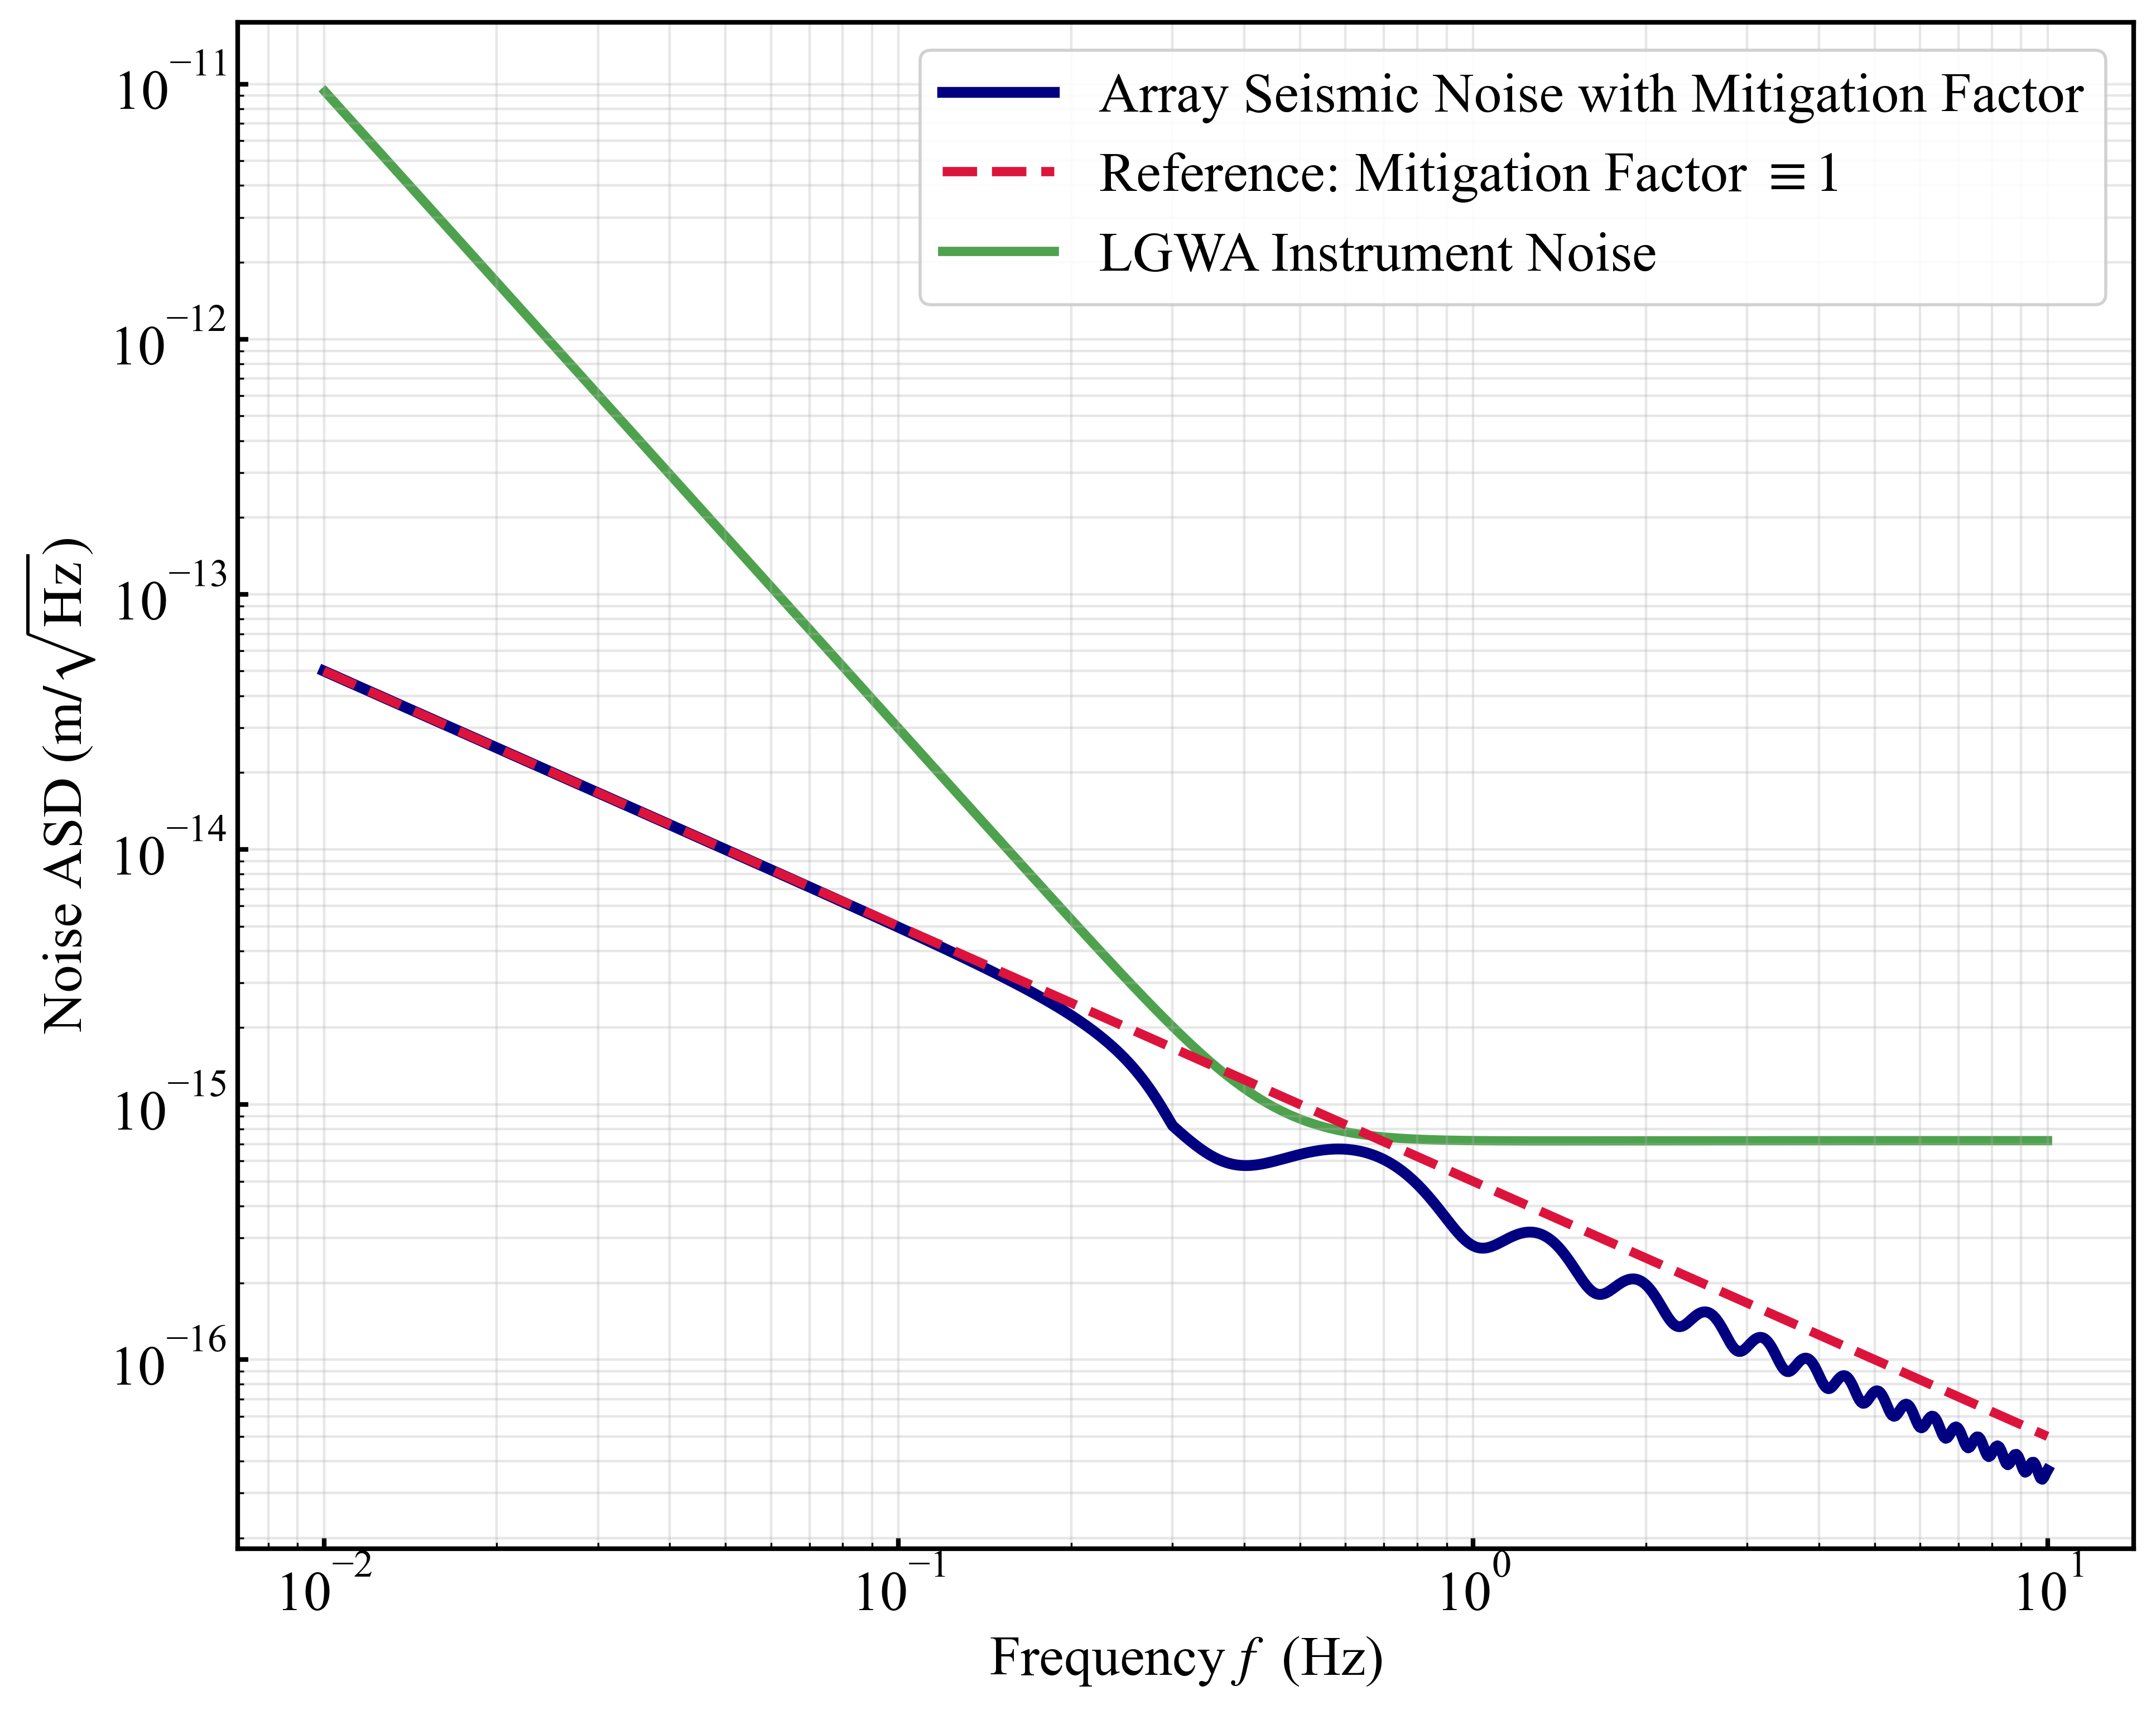

In [14]:
import matplotlib.pyplot as plt

# 全局绘图参数 (严格保持不变)
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 18
plt.rcParams['figure.dpi'] = 150
plt.rcParams['axes.linewidth'] = 1.5
plt.rcParams['xtick.major.width'] = 1.5
plt.rcParams['ytick.major.width'] = 1.5
plt.rcParams['xtick.direction'] = 'in'
plt.rcParams['ytick.direction'] = 'in'

# ==========================================
# 绘图函数
# ==========================================
def plot_noise_results(f, noise_a, noise_b, 
                       lgwa_f=None, lgwa_asd=None):
    plt.figure(figsize=(10, 8), dpi=400)
    
    # 1. 包含几何因子的完整计算结果
    plt.loglog(f, noise_a, 
               color='navy', linewidth=3.5, 
               label=r'Array Seismic Noise with Mitigation Factor')
    
    # 2. 几何因子恒等于1的对照组
    plt.loglog(f, noise_b, 
               color='crimson', linestyle='--', linewidth=3, 
               label=r'Reference: Mitigation Factor $\equiv 1$')
               
    # 3. 目标灵敏度 / 先前预期灵敏度 (直接绘制)
    if lgwa_f is not None and lgwa_asd is not None:
        plt.loglog(lgwa_f, lgwa_asd, 
                   color='forestgreen',  linewidth=3, 
                   zorder=1, alpha=0.8, # 置于底层并增加轻微透明度以防遮挡
                   label=r'LGWA Instrument Noise')
    
    # 图表装饰：标签已修正为要求的物理单位
    plt.xlabel('Frequency $f~$ (Hz)', fontsize=18)
    plt.ylabel(r'Noise ASD ($\mathrm{m}/\sqrt{\mathrm{Hz}}$)', fontsize=18)
    #plt.title(r'Geometric effect in array noise', fontsize=20)
    
    plt.grid(True, which="both", ls="-", alpha=0.3)
    plt.legend(fontsize=18, loc='best', frameon=True, fancybox=True, framealpha=0.9)
    plt.tick_params(axis='both', which='major', labelsize=18)
    
    plt.tight_layout()
    plt.show()

# 调用绘图
plot_noise_results(freq_array, noise_full, noise_flat, 
                   lgwa_f=lgwa_f, lgwa_asd=lgwa_asd)